In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 3060 Laptop GPU
11.8
['sm_37', 'sm_50', 'sm_60', 'sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'compute_37']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
seed = 2
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method']
# weather_features = ['Solar', 'Precipitation', 'AirTemp', 'Vapor_Pressure', 'AtmPressure', 'RelHumidity']
weather_features = []
canopy_temp_features = ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
# canopy_temp_features = []

features = vi_features + canopy_temp_features + weather_features
output_variable = 'GYLD_kg_m3'


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

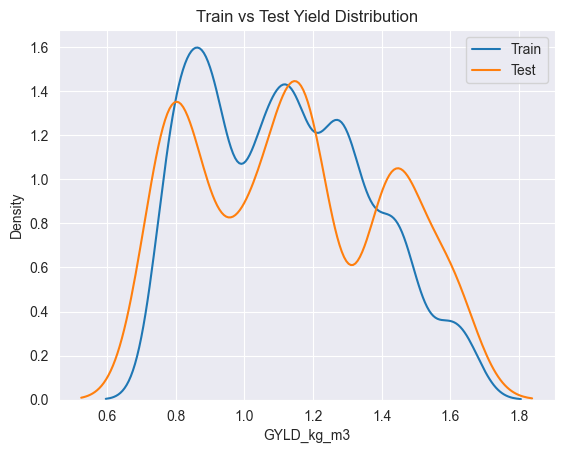

In [5]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets_v2.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [7]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1084
test_df_scaled Rows with at least one NaN: 354


In [ ]:
# print(X_test_scaled.shape)

In [8]:


def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch, lengths in model_train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lgths = lengths.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch, lgths)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [9]:
from sklearn.metrics import  mean_squared_error

def evaluate_model(model, val_loader, output_variable_scaler, doInverseTransformScale = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if doInverseTransformScale:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse

In [10]:
window_size = 30
pad_value = -99

K-fold cross validation

In [ ]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset

def k_fold_cross_validation(batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold = make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name=""
        )

        r2, mse = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f"Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n✅ Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [ ]:
import optuna
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

search_space = {
    "hidden_size": [8, 16, 32 , 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr":  [0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [8, 16, 32, 64],
}

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


In [ ]:
# sampler = optuna.samplers.GridSampler(search_space)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


In [11]:


cols_to_pad = canopy_temp_features
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [ ]:
from torch.nn.utils.rnn import pack_padded_sequence
from helper import make_progressive_windows
from vi_dataset import VIDataset
from model_definitions import GRUModel

def validation_with_test(trial_id, batch_size, epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled, lengths_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled, lengths_test = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

    train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1 , dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader,
        num_epochs = epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [ ]:
epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [20]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=80)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-10 12:09:58,576] A new study created in memory with name: no-name-b035b5cd-b4d9-41c5-b6cf-c62bec8822d6
C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4261439841574355 and num_layers=1
  warnings.warn(


Epoch [1/1000] - Train Loss: 0.17400
Epoch [2/1000] - Train Loss: 0.15715
Epoch [3/1000] - Train Loss: 0.14953
Epoch [4/1000] - Train Loss: 0.14592
Epoch [5/1000] - Train Loss: 0.14396
Epoch [6/1000] - Train Loss: 0.14268
Epoch [7/1000] - Train Loss: 0.14171
Epoch [8/1000] - Train Loss: 0.14096
Epoch [9/1000] - Train Loss: 0.14020
Epoch [10/1000] - Train Loss: 0.13950
Epoch [11/1000] - Train Loss: 0.13880
Epoch [12/1000] - Train Loss: 0.13805
Epoch [13/1000] - Train Loss: 0.13731
Epoch [14/1000] - Train Loss: 0.13651
Epoch [15/1000] - Train Loss: 0.13566
Epoch [16/1000] - Train Loss: 0.13471
Epoch [17/1000] - Train Loss: 0.13370
Epoch [18/1000] - Train Loss: 0.13245
Epoch [19/1000] - Train Loss: 0.13112
Epoch [20/1000] - Train Loss: 0.12955
Epoch [21/1000] - Train Loss: 0.12774
Epoch [22/1000] - Train Loss: 0.12556
Epoch [23/1000] - Train Loss: 0.12320
Epoch [24/1000] - Train Loss: 0.12075
Epoch [25/1000] - Train Loss: 0.11861
Epoch [26/1000] - Train Loss: 0.11664
Epoch [27/1000] - Tra

[I 2025-11-10 12:26:44,721] Trial 0 finished with value: 0.2663502097129822 and parameters: {'hidden_size': 8, 'num_layers': 1, 'dropout': 0.4261439841574355, 'lr': 0.0001270919130345217, 'weight_decay': 4.5152570640576025e-10, 'batch_size': 8}. Best is trial 0 with value: 0.2663502097129822.


Epoch [1000/1000] - Train Loss: 0.02133
 R²: 0.2664
Epoch [1/1000] - Train Loss: 0.14226
Epoch [2/1000] - Train Loss: 0.11772
Epoch [3/1000] - Train Loss: 0.11117
Epoch [4/1000] - Train Loss: 0.09917
Epoch [5/1000] - Train Loss: 0.07664
Epoch [6/1000] - Train Loss: 0.06048
Epoch [7/1000] - Train Loss: 0.04191
Epoch [8/1000] - Train Loss: 0.04207
Epoch [9/1000] - Train Loss: 0.03239
Epoch [10/1000] - Train Loss: 0.02510
Epoch [11/1000] - Train Loss: 0.02174
Epoch [12/1000] - Train Loss: 0.02141
Epoch [13/1000] - Train Loss: 0.02007
Epoch [14/1000] - Train Loss: 0.02117
Epoch [15/1000] - Train Loss: 0.02368
Epoch [16/1000] - Train Loss: 0.02194
Epoch [17/1000] - Train Loss: 0.01574
Epoch [18/1000] - Train Loss: 0.01558
Epoch [19/1000] - Train Loss: 0.01485
Epoch [20/1000] - Train Loss: 0.01192
Epoch [21/1000] - Train Loss: 0.01117
Epoch [22/1000] - Train Loss: 0.00818
Epoch [23/1000] - Train Loss: 0.00826
Epoch [24/1000] - Train Loss: 0.01035
Epoch [25/1000] - Train Loss: 0.01786
Epoch [

[I 2025-11-10 12:27:09,875] Trial 1 finished with value: 0.2701647877693176 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.43108236483633394, 'lr': 0.0067342422408135805, 'weight_decay': 7.77621179254545e-06, 'batch_size': 32}. Best is trial 1 with value: 0.2701647877693176.


...

Epoch [216/1000] - Train Loss: 0.00041
Early stopping triggered.
 R²: 0.0869
Epoch [1/1000] - Train Loss: 0.13461
Epoch [2/1000] - Train Loss: 0.11223
Epoch [3/1000] - Train Loss: 0.08213
Epoch [4/1000] - Train Loss: 0.05334
Epoch [5/1000] - Train Loss: 0.04424
Epoch [6/1000] - Train Loss: 0.02787
Epoch [7/1000] - Train Loss: 0.01778
Epoch [8/1000] - Train Loss: 0.01530
Epoch [9/1000] - Train Loss: 0.01388
Epoch [10/1000] - Train Loss: 0.01638
Epoch [11/1000] - Train Loss: 0.01328
Epoch [12/1000] - Train Loss: 0.01215
Epoch [13/1000] - Train Loss: 0.01101
Epoch [14/1000] - Train Loss: 0.00871
Epoch [15/1000] - Train Loss: 0.01034
Epoch [16/1000] - Train Loss: 0.00849
Epoch [17/1000] - Train Loss: 0.00780
Epoch [18/1000] - Train Loss: 0.02712
Epoch [19/1000] - Train Loss: 0.02863
Epoch [20/1000] - Train Loss: 0.02845
Epoch [21/1000] - Train Loss: 0.02195
Epoch [22/1000] - Train Loss: 0.00946
Epoch [23/1000] - Train Loss: 0.01234
Epoch [24/1000] - Train Loss: 0.00918
Epoch [25/1000] - Tr

[I 2025-11-10 15:50:37,843] Trial 78 finished with value: 0.2650942802429199 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2183589365919847, 'lr': 0.009795303360070697, 'weight_decay': 4.737533588612271e-09, 'batch_size': 16}. Best is trial 69 with value: 0.41606104373931885.


Epoch [63/1000] - Train Loss: 0.00936
Early stopping triggered.
 R²: 0.2651
Epoch [1/1000] - Train Loss: 0.13879
Epoch [2/1000] - Train Loss: 0.10461
Epoch [3/1000] - Train Loss: 0.07639
Epoch [4/1000] - Train Loss: 0.04605
Epoch [5/1000] - Train Loss: 0.02962
Epoch [6/1000] - Train Loss: 0.02000
Epoch [7/1000] - Train Loss: 0.01716
Epoch [8/1000] - Train Loss: 0.01427
Epoch [9/1000] - Train Loss: 0.01525
Epoch [10/1000] - Train Loss: 0.00998
Epoch [11/1000] - Train Loss: 0.02874
Epoch [12/1000] - Train Loss: 0.01283
Epoch [13/1000] - Train Loss: 0.00650
Epoch [14/1000] - Train Loss: 0.01233
Epoch [15/1000] - Train Loss: 0.00886
Epoch [16/1000] - Train Loss: 0.00545
Epoch [17/1000] - Train Loss: 0.00516
Epoch [18/1000] - Train Loss: 0.00354
Epoch [19/1000] - Train Loss: 0.00325
Epoch [20/1000] - Train Loss: 0.00333
Epoch [21/1000] - Train Loss: 0.00279
Epoch [22/1000] - Train Loss: 0.00291
Epoch [23/1000] - Train Loss: 0.00261
Epoch [24/1000] - Train Loss: 0.00274
Epoch [25/1000] - Tra

[I 2025-11-10 15:51:45,384] Trial 79 finished with value: 0.40765148401260376 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.01777279077263383, 'lr': 0.009013393693748335, 'weight_decay': 1.0867131320512586e-09, 'batch_size': 16}. Best is trial 69 with value: 0.41606104373931885.


Epoch [95/1000] - Train Loss: 0.00128
Early stopping triggered.
 R²: 0.4077
Best R²: 0.4161
Best hyperparameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.07420456457400194, 'lr': 0.00981026753766152, 'weight_decay': 8.506150589531528e-08, 'batch_size': 16}


In [12]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import GRUModel
# Best R²: 0.4483, Used dataset v2, only the VIs and lepton temp, without the length in GRU
# criterion_method = L1 Loss
best_gru_params =  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.10344360354230203, 'lr': 0.0002476906474606584, 'weight_decay': 0.0005347879641161282, 'batch_size': 8}

# Best R²: 0.4605
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.03884806018039991, 'lr': 0.00042173321148857924, 'weight_decay': 0.0004972207591747834, 'batch_size': 64}

# Used the dataset v3, only the VIs, saved as /best_gru_models/best_model_hyper_param_3.pth
# Best R²: 0.4161
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.07420456457400194, 'lr': 0.00981026753766152, 'weight_decay': 8.506150589531528e-08, 'batch_size': 16}

best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.10344360354230203 and num_layers=1
  warnings.warn(


In [13]:
from helper import make_progressive_windows
from vi_dataset import VIDataset
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

X_train_scaled, y_train_scaled, lengths_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled, lengths_test = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:

# Optional: Train again with best hyper parameters


epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

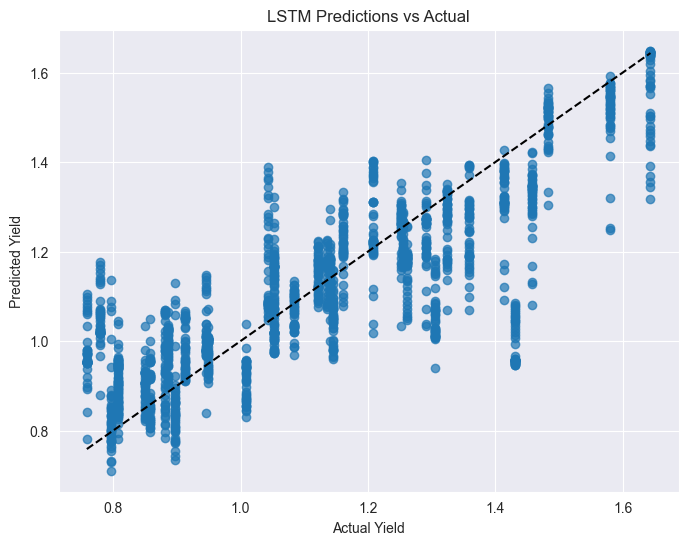

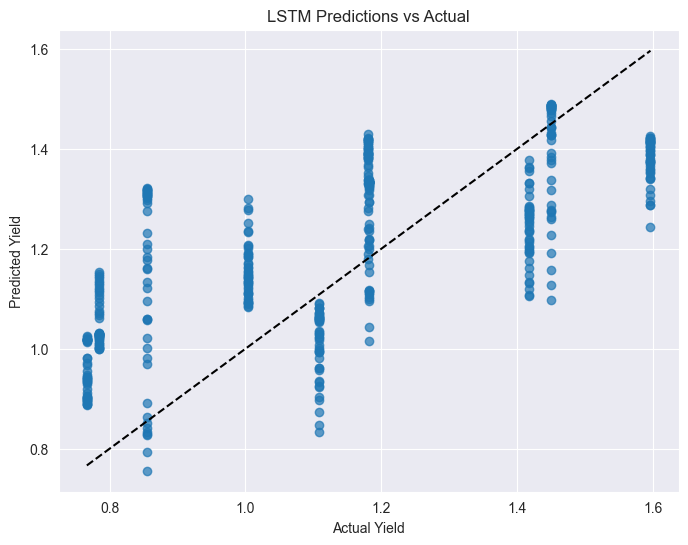

Train R²: 0.6743, Train MSE: 0.0187
Test R²: 0.4418, Test MSE: 0.0420


In [14]:
# from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_gru_models/best_model_hyper_param_1.pth", map_location=device))

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [24]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_3.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_3.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_3.save")

['best_gru_models/scalers/scaler_y_3.save']